In [ ]:
import pickle

with open("../../data/second_iteration/booking_intent_artifact.pkl", "rb") as f:
    artifact = pickle.load(f)

model = artifact["model"]
le = artifact["label_encoder"]
feature_columns = artifact["feature_columns"]
categorical_columns = artifact["categorical_columns"]

In [89]:
import re
import numpy as np
import pandas as pd
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(model="text-embedding-3-small")

def extract_classical_features(messages: list[dict]) -> dict:
    user_msgs = [m["text"] for m in messages if m["role"] == "user"]
    user_turns = len([m for m in messages if m["role"] == "user"])
    bot_turns = len([m for m in messages if m["role"] == "bot"])
    user_lens = [len(t) for t in user_msgs]
    booking_confirmed = (
        True
        if True in [True for m in messages if m["booking"] == "confirmed"]
        else False
    )

    return {
        "num_turns": len(messages),
        "num_user_turns": user_turns,
        "num_bot_turns": bot_turns,
        "avg_user_msg_len": sum(user_lens) / len(user_lens) if user_lens else 0,
        "booking_confirmed": booking_confirmed,
    }

async def extract_llm_features(messages: list[dict], agent) -> dict:

    EXTRACTION_PROMPT = """
    Analyze this hotel chatbot conversation and extract the following features.

    Conversation:
    {conversation_text}
    """
    
    text = "\n".join(f"{m['role']}: {m['text']}" for m in messages)
    result = await agent.ainvoke({
        "messages": [{"role": "user", "content": EXTRACTION_PROMPT.format(conversation_text=text)}]
    })
    return result["structured_response"].model_dump()

async def get_embedding(messages: list[dict]) -> list[float]:
    user_text = "\n".join(m["text"] for m in messages if m["role"] == "user")
    return await embeddings_model.aembed_query(user_text)

In [90]:
async def build_feature_row(messages: list[dict], agent) -> pd.DataFrame:
    classical = extract_classical_features(messages)
    llm_features = await extract_llm_features(messages, agent)
    embedding = await get_embedding(messages)

    embedding_dict = {f"emb_{i}": v for i, v in enumerate(embedding)}

    row = {**classical, **llm_features, **embedding_dict}
    row_df = pd.DataFrame([row])

    # ensure exact same column set/order as training, and same dtypes
    row_df = row_df.reindex(columns=feature_columns)
    for col in categorical_columns:
        row_df[col] = row_df[col].astype("category")

    return row_df

In [91]:
async def predict_intent(messages: list[dict], agent) -> str:
    row_df = await build_feature_row(messages, agent)
    proba = model.predict(row_df, num_iteration=model.best_iteration)
    predicted_idx = np.argmax(proba, axis=1)[0]
    predicted_label = le.inverse_transform([predicted_idx])[0]
    return predicted_label, proba[0]

In [92]:
from enum import StrEnum
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain.agents.structured_output import ProviderStrategy

class PriceSensitivity(StrEnum):
    NONE = "none"
    MENTIONED = "mentioned"
    EXPLICIT_BUDGET = "explicit_budget"
    
    
class ExtractedFeatures(BaseModel):
    mentions_specific_dates: bool = Field(
        description="Guest mentioned concrete check-in/check-out dates"
    )
    mentions_room_type: bool = Field(
        description="Guest specified a room type or category"
    )
    num_distinct_questions: int = Field(
        description="Count of distinct discovery/comparison questions asked"
    )
    urgency_signals: bool = Field(
        description="Language suggesting time pressure or immediate need"
    )
    comparison_count: int = Field(
        description="Number of options/prices/dates being compared"
    )
    guest_persona_hint: str = Field(
        description="Inferred persona: family/business/solo/couple/unclear"
    )
    attractions_mentioned: bool = Field(
        description="Guest mentioned nearby attractions"
    )
    specific_location_mentioned: bool = Field(
        description="Guest mentions a specific location, city or spot"
    )
    reached_payment_step: bool = Field(
        description="Guest reached a hold, confirmation, or payment/checkout step (e.g. was asked for name, email, billing details, or to confirm a hold), regardless of whether payment was actually completed"
    )
    language: str = Field(description="Language the guest is speaking")
    price_sensitivity: PriceSensitivity = Field(
        description="Way the guest was referring to monetary values"
    )

agent = create_agent(
    "gpt-5.4-mini", response_format=ProviderStrategy(ExtractedFeatures)
)

### Test the model here!

In [71]:
# new_conversation = [
#     {"role": "user", "text": "Do you have any rooms available next week?"},
#     {"role": "bot", "text": "Yes! What dates are you thinking?"},
#     {"role": "user", "text": "Maybe the 12th to the 15th, not sure yet."},
#     {"role": "bot", "text": "We have a room available, for 200€ a night"},
# ]

new_conversation = [
    {"role": "user", "text": "How much for a full body spa massage", "booking": None},
    {"role": "bot", "text": "Hello, a full body spa massage costs 100€, would you like to make a booking?", "booking": None},                                
]

label, probabilities = await predict_intent(new_conversation, agent)
print(f"Predicted: {label}")
print(f"Probabilities: {dict(zip(le.classes_, probabilities))}")

Predicted: low
Probabilities: {'abandoned': np.float64(0.009606756994342746), 'high': np.float64(0.08129808371204374), 'low': np.float64(0.8578241576254967), 'medium': np.float64(0.05127100166811688)}


### Hand Authored Evaluation

In [93]:
hand_authored_eval = [
    {
        "messages": [
            {"role": "user", "text": "Hi, can you provide me with a list of hotel facilities?", "booking": None},
            {"role": "bot", "text": "Of course, right now we have an interior pool, an exterior pool for kids and adults, a restaurant, a spa and a pool bar.", "booking": None},
        ],
        "true_label": "low",
        "session_id": "manual_001",
    },
    {
        "messages": [
            {"role": "user", "text": "Hello, which attractions are available close to the hotel?", "booking": None},
            {"role": "bot", "text": "Close to the hotel, we have the museum of human history and the sistine chapel", "booking": None},
        ],
        "true_label": "low",
        "session_id": "manual_002",
    },
    {
        "messages": [
            {"role": "user", "text": "Provide a list of restaurants closeby", "booking": None},
            {"role": "bot", "text": "There's the Dragon's Keg, a traditional scottish restaurant, and Occult, a 2 michelin star restaurant.", "booking": None},
        ],
        "true_label": "low",
        "session_id": "manual_003",
    },
    {
        "messages": [
            {"role": "user", "text": "Provide a list of restaurants closeby", "booking": None},
            {"role": "bot", "text": "There's the Dragon's Keg, a traditional scottish restaurant, and Occult, a 2 michelin star restaurant.", "booking": None},
        ],
        "true_label": "low",
        "session_id": "manual_004",
    },
    
    {
        "messages": [
            {"role": "user", "text": "Hello, can you provide me a list of the dishes of the day for your restaurant, together with the pricing?", "booking": None},
            {"role": "bot", "text": "Good afternoon, of course. Today have Margheritta Pizza for 15€ and a Gaspacho for 6€", "booking": None},
        ],
        "true_label": "medium",
        "session_id": "manual_005",
    },
    {
        "messages": [
            {"role": "user", "text": "Can you show me a comparison on booking prices for different rooms from the 12th to 14th May?", "booking": None},
            {"role": "bot", "text": "Our basic double room stays at 144€ a night, and our suite is 200€", "booking": None},
        ],
        "true_label": "medium",
        "session_id": "manual_006",
    },
    {
        "messages": [
            {"role": "user", "text": "Hi, I have booked a double room with terrace for the 14th to 16th August, can you inform me on the cancellation fee?", "booking": None},
            {"role": "bot", "text": "Of course, can you provide me the reservation number?", "booking": None},
            {"role": "user", "text": "ASF435JK", "booking": None},
            {"role": "bot", "text": "There's a cancellation fee of 30€ until the 13th August, which then becomes full price.", "booking": None}                                    
        ],
        "true_label": "medium",
        "session_id": "manual_007",
    },
    {
        "messages": [
            {"role": "user", "text": "How much for a full body spa massage", "booking": None},
            {"role": "bot", "text": "Hello, a full body spa massage costs 100€, would you like to make a booking?", "booking": None},                                
        ],
        "true_label": "medium",
        "session_id": "manual_008",
    },
    
    {
        "messages": [
            {"role": "user", "text": "Hi, can you provide me with the prices on various spa massages", "booking": None},
            {"role": "bot", "text": "Yes, our most common offer is a full body massage for 100€ per person, which is 1 hour, and a back massage for 50€ per person, which is 30 minutes.", "booking": None},
            {"role": "user", "text": "I want to book two full body massages for the 13th of August, which times do you have available?", "booking": None},
            {"role": "bot", "text": "We have a time available at 3 p.m., would you like to schedule it?", "booking": None},
            {"role": "user", "text": "Yes, please", "booking": None},
            {"role": "bot", "text": "Booking confirmed", "booking": True},
        ],
        "true_label": "high",
        "session_id": "manual_009",
    },
    {
        "messages": [
            {"role": "user", "text": "Can I get extra towels and pillows to room 412?", "booking": None}, 
            {"role": "bot", "text": "Absolutely—two towels and two pillows for room 412. Anything else?", "booking": None}, 
            {"role": "user", "text": "That's all, thanks.", "booking": None}, 
            {"role": "bot", "text": "Done. Housekeeping will deliver within 10–15 minutes.", "booking": None, "booking": None}
        ],
        "true_label": "high",
        "session_id": "manual_010",
    },
    {
        "messages": [
            {"role": "user", "text": "Do you have sea-view rooms this weekend?", "booking": None}, 
            {"role": "bot", "text": "Yes: Standard €150, Superior €190 with balcony.", "booking": None}, 
            {"role": "user", "text": "What's the difference?", "booking": None}, 
            {"role": "bot", "text": "Superior has a balcony and premium breakfast.", "booking": None}, 
            {"role": "user", "text": "I'll take Superior. Maria, maria@example.com.", "booking": None},
            {"role": "bot", "text": "Booking confirmed", "booking": True},
        ],
        "true_label": "high",
        "session_id": "manual_011",
    },
    {
        "messages": [
            {"role": "user", "text": "Hi, availability for 12–14 Oct for 2 adults?", "booking": None}, 
            {"role": "bot", "text": "Available: Deluxe €180/night. Proceed to book?", "booking": None}, 
            {"role": "user", "text": "Yes, book the Deluxe.", "booking": None}, 
            {"role": "bot", "text": "Name and email, please.", "booking": None}, 
            {"role": "user", "text": "John Smith, john@example.com", "booking": None},
            {"role": "bot", "text": "Booking confirmed", "booking": True},
        ],
        "true_label": "high",
        "session_id": "manual_012",
    },
    {
        "messages": [
            {"role": "user", "text": "hii do u have rooms this wkend? just me n my partner", "booking": None},
            {"role": "bot", "text": "Yes, we have availability this weekend. Would you like a double or twin room?", "booking": None},
            {"role": "user", "text": "double is fine, how much", "booking": None},
            {"role": "bot", "text": "A double room this weekend is €120/night, 2 nights = €240. Want me to hold it?", "booking": None},
            {"role": "user", "text": "let me check with her and get back to u", "booking": None},
        ],
        "true_label": "abandoned",
        "session_id": "manual_013",
    },
    {
        "messages": [
            {"role": "user", "text": "Hi, availability for 12–14 Oct for 2 adults?", "booking": None}, 
            {"role": "bot", "text": "Available: Double Room €180/night. Proceed to book?", "booking": None}, 
            {"role": "user", "text": "Yes, book the Deluxe.", "booking": None}, 
            {"role": "bot", "text": "Name and email, please.", "booking": None},
        ],
        "true_label": "abandoned",
        "session_id": "manual_014",
    },
    {
        "messages": [
            {"role": "user", "text": "Hi, I wish to make a reservation from 10-17 Aug", "booking": None}, 
            {"role": "bot", "text": "Available: Suite €150/night. Proceed to book?", "booking": None}, 
            {"role": "user", "text": "Is there any other room during that week, even if it's during less days", "booking": None}, 
            {"role": "bot", "text": "There's a Double room from 11-16 Aug, it's 100€/night. Do you wish to book?", "booking": None},
            {"role": "user", "text": "Yes, proceed with the booking", "booking": None},
            {"role": "bot", "text": "Name and email, please.", "booking": None}
        ],
        "true_label": "abandoned",
        "session_id": "manual_015",
    },
    {
        "messages": [
            {"role": "user", "text": "Hello, I want to book a spa back massage on the 12th August", "booking": None}, 
            {"role": "bot", "text": "There's one available at 15 p.m., do you wish to book?", "booking": None}, 
            {"role": "user", "text": "Yes", "booking": None}, 
            {"role": "bot", "text": "Provide your billing address", "booking": None},
        ],
        "true_label": "abandoned",
        "session_id": "manual_016",
    }
    
    # ... 15-20 total, spread across your 4 classes
]

In [94]:
results = [await predict_intent(c["messages"], agent) for c in hand_authored_eval]

y_true, y_pred, y_proba_list = [], [], []
for conv, (pred_label, proba) in zip(hand_authored_eval, results):
    if pred_label is None:
        continue
    y_true.append(conv["true_label"])
    y_pred.append(pred_label)
    y_proba_list.append(proba)

y_proba = np.array(y_proba_list)
y_true_encoded = le.transform(y_true)
y_pred_encoded = le.transform(y_pred)

### Metrics

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   abandoned       0.67      0.50      0.57         4
        high       0.33      0.25      0.29         4
         low       0.57      1.00      0.73         4
      medium       0.67      0.50      0.57         4

    accuracy                           0.56        16
   macro avg       0.56      0.56      0.54        16
weighted avg       0.56      0.56      0.54        16

AGGREGATE METRICS
Accuracy:              0.5625
Balanced accuracy:     0.5625
Macro F1:              0.5390
Weighted F1:           0.5390
Cohen's Kappa:         0.4167
Matthews CorrCoef:     0.4303
Log loss:              1.3334
Macro ROC-AUC (OvR):   0.8490
Macro PR-AUC:          0.7625
PER-CLASS METRICS
           precision  recall     f1  pr_auc  support
class                                               
abandoned      0.667    0.50  0.571   0.817        4
high           0.333    0.25  0.286   0.515        4
low            0.571    1

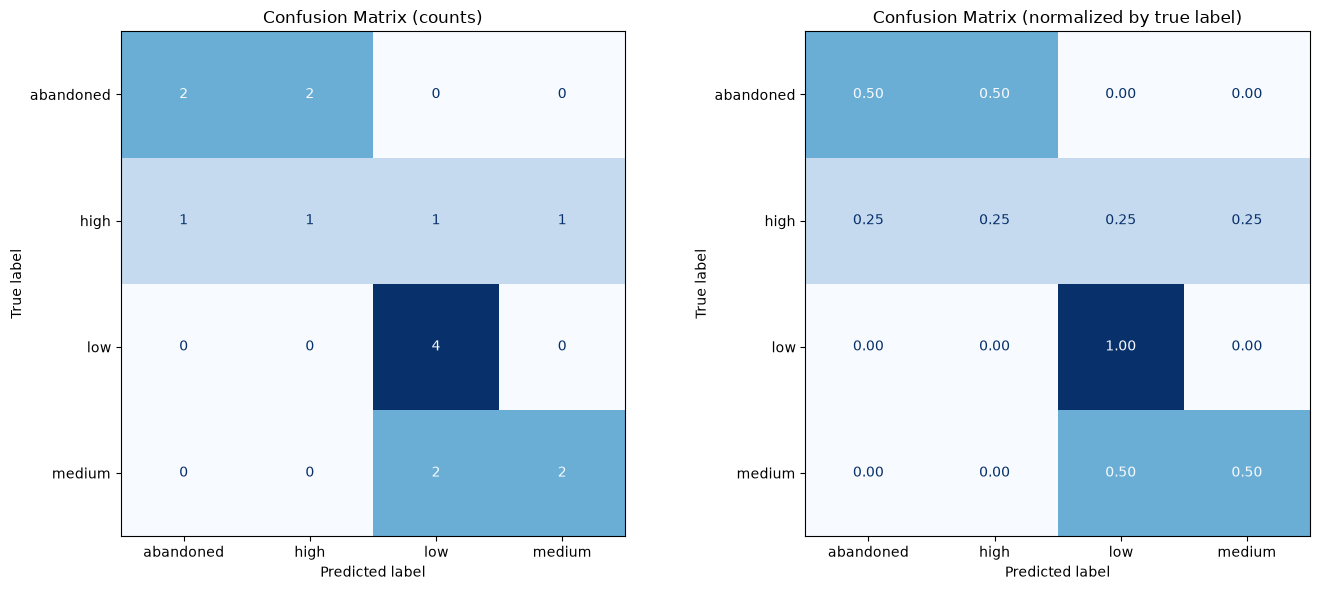

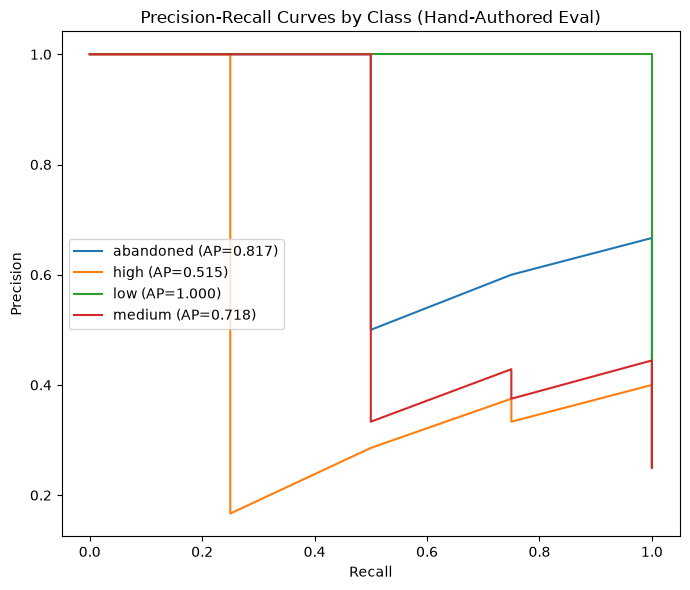

CONFIDENCE DIAGNOSTIC
Mean max probability:            0.8626
Min max probability:             0.3977
Mean confidence when correct:    0.9472
Mean confidence when incorrect:  0.7539


In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, balanced_accuracy_score,
    f1_score, precision_recall_fscore_support,
    log_loss, cohen_kappa_score, matthews_corrcoef,
    roc_auc_score, average_precision_score,
    ConfusionMatrixDisplay, precision_recall_curve
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true_encoded, y_pred_encoded, target_names=le.classes_))

print("=" * 60)
print("AGGREGATE METRICS")
print("=" * 60)
print(f"Accuracy:              {accuracy_score(y_true_encoded, y_pred_encoded):.4f}")
print(f"Balanced accuracy:     {balanced_accuracy_score(y_true_encoded, y_pred_encoded):.4f}")
print(f"Macro F1:              {f1_score(y_true_encoded, y_pred_encoded, average='macro'):.4f}")
print(f"Weighted F1:           {f1_score(y_true_encoded, y_pred_encoded, average='weighted'):.4f}")
print(f"Cohen's Kappa:         {cohen_kappa_score(y_true_encoded, y_pred_encoded):.4f}")
print(f"Matthews CorrCoef:     {matthews_corrcoef(y_true_encoded, y_pred_encoded):.4f}")
print(f"Log loss:              {log_loss(y_true_encoded, y_proba, labels=range(len(le.classes_))):.4f}")

y_true_binarized = label_binarize(y_true_encoded, classes=range(len(le.classes_)))

# ROC-AUC / PR-AUC require at least one positive and one negative example per class in the sample
try:
    macro_roc_auc = roc_auc_score(y_true_encoded, y_proba, multi_class="ovr", average="macro", labels=range(len(le.classes_)))
    print(f"Macro ROC-AUC (OvR):   {macro_roc_auc:.4f}")
except ValueError as e:
    print(f"Macro ROC-AUC: could not compute ({e})")

macro_pr_auc = average_precision_score(y_true_binarized, y_proba, average="macro")
print(f"Macro PR-AUC:          {macro_pr_auc:.4f}")


precision, recall, f1, support = precision_recall_fscore_support(
    y_true_encoded, y_pred_encoded, average=None, labels=range(len(le.classes_)), zero_division=0
)

pr_auc_per_class = [
    average_precision_score(y_true_binarized[:, i], y_proba[:, i])
    for i in range(len(le.classes_))
]

metrics_df = pd.DataFrame({
    "class": le.classes_,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "pr_auc": pr_auc_per_class,
    "support": support,
}).set_index("class")

print("=" * 60)
print("PER-CLASS METRICS")
print("=" * 60)
print(metrics_df.round(3))


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_raw = confusion_matrix(y_true_encoded, y_pred_encoded, labels=range(len(le.classes_)))
ConfusionMatrixDisplay(cm_raw, display_labels=le.classes_).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix (counts)")

cm_norm = confusion_matrix(y_true_encoded, y_pred_encoded, labels=range(len(le.classes_)), normalize="true")
ConfusionMatrixDisplay(cm_norm, display_labels=le.classes_).plot(ax=axes[1], cmap="Blues", values_format=".2f", colorbar=False)
axes[1].set_title("Confusion Matrix (normalized by true label)")

plt.tight_layout()
plt.savefig("../../data/hand_authored_confusion_matrix.png", dpi=150)
plt.show()


fig, ax = plt.subplots(figsize=(7, 6))
for i, label in enumerate(le.classes_):
    p, r, _ = precision_recall_curve(y_true_binarized[:, i], y_proba[:, i])
    ax.plot(r, p, label=f"{label} (AP={pr_auc_per_class[i]:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves by Class (Hand-Authored Eval)")
ax.legend()
plt.tight_layout()
plt.savefig("../../data/hand_authored_pr_curves.png", dpi=150)
plt.show()


max_proba = y_proba.max(axis=1)
correct_mask = y_true_encoded == y_pred_encoded

print("=" * 60)
print("CONFIDENCE DIAGNOSTIC")
print("=" * 60)
print(f"Mean max probability:            {max_proba.mean():.4f}")
print(f"Min max probability:             {max_proba.min():.4f}")
print(f"Mean confidence when correct:    {max_proba[correct_mask].mean():.4f}")
print(f"Mean confidence when incorrect:  {max_proba[~correct_mask].mean() if (~correct_mask).any() else float('nan'):.4f}")